# Проект №1: Предсказание длительности поездки такси в Нью-Йорке 

## Описание задачи

Цель проекта — построить модель машинного обучения, которая предсказывает общую длительность поездки такси (в секундах) на основе данных о поездках.

Задача из соревнования Kaggle, основанная на данных NYC Taxi

## Данные

- **train.csv** — обучающая выборка (1 458 644 поездки)
- **test.csv** — тестовая выборка (625 134 поездки)* не спользовалась
- Для проекта используется выборка из 50 000 строк (для ускорения обучения)

**Признаки:**
- `id` — уникальный идентификатор поездки
- `vendor_id` — код поставщика такси
- `pickup_datetime` — дата и время начала поездки
- `dropoff_datetime` — дата и время окончания поездки
- `passenger_count` — количество пассажиров
- `pickup_longitude` / `pickup_latitude` — координаты посадки
- `dropoff_longitude` / `dropoff_latitude` — координаты высадки
- `store_and_fwd_flag` — флаг хранения данных (Y/N)
- `trip_duration` — целевая переменная (длительность поездки в секундах)

## Метрика оценки

В данном проекте для сравнения моделей используются:
- **RMSE** (Root Mean Square Error)
- **MAE** (Mean Absolute Error)
- **MAPE** (Mean Absolute Percentage Error)
- **R²** (Коэффициент детерминации)

## Используемые методы

1. **EDA** — исследовательский анализ данных, визуализация распределений
2. **Feature Engineering** — создание новых признаков (час, день недели, месяц и т.д.)
3. **Масштабирование** — StandardScaler для числовых признаков
4. **Обучение моделей**:
   - Линейные модели (Linear Regression, Ridge, Lasso)
   - Метрические методы (k-NN с подбором гиперпараметров)
   - Ансамбли (Random Forest, XGBoost, LightGBM, CatBoost)
   - Нейросеть (PyTorch)*попытка
5. **Анализ**:
   - Важность признаков
   - L1-регуляризация (разреживание весов)

## Результат

Модель, которая предсказывает длительность поездки с минимальной ошибкой, а также понимание того, какие факторы (время суток, день недели, поставщик) влияют на продолжительность поездки.


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df = pd.read_csv('train.csv', nrows=50000)
print(df.head())
print(df.info())

          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -73.999481   
2                1        -73.979027        40.763939         -74.005333   
3                1        -74.010040        40.719971         -74.012268   
4                1        -73.973053        40.793209         -73.972923   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.765602                  N            455  
1         40.731

пропусков нет

## Исследовательский анализ данных (EDA)

Смотрим, как распределены поездки по длительности, чтобы понять нормальные значения, посмотреть выбросы/аномалии

**1. Гистограмма распределения длительность поездок в данных:**
- по оси X — длительность поездки в секундах
- по оси Y — сколько поездок с такой длительностью

**2.Boxplot для разброса данных длительности поездок и выяления выбросов:**
- ящик показывает, где находятся 50% всех данных
- линия внутри — медиана
- точки за усами — выбросы
- видно, что есть поездки длительностью более 4000 секунд (это > 1 часа)

**3.Статистика**
- среднее арифметическое поездок
- медиана
- самая длинная поездка

Если среднее и медиана сильно отличаются, значит есть большие выбросы, которые тянут среднее вверх


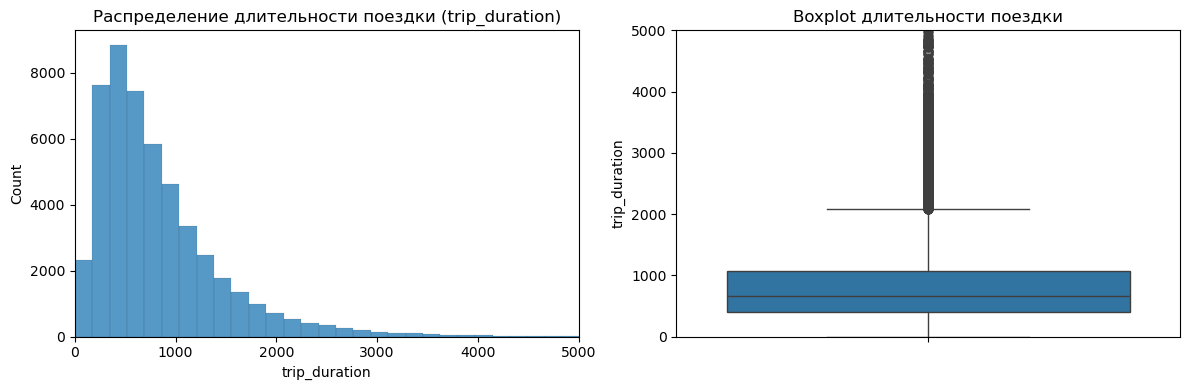

Средняя длительность поездки: 950 секунд
Медианная длительность поездки: 659 секунд
Максимальная длительность: 86357 секунд


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2 графика рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма, сколько поездок попадает в каждый интервал времени
sns.histplot(df['trip_duration'], bins=500, ax=axes[0])
axes[0].set_title('Распределение длительности поездки (trip_duration)')
axes[0].set_xlim(0, 5000)

# Boxplot -разброс данных и выбросы
sns.boxplot(y=df['trip_duration'], ax=axes[1])
axes[1].set_title('Boxplot длительности поездки')
axes[1].set_ylim(0, 5000)

#показ картинки
plt.tight_layout()
plt.show()

#статистика
print(f"Средняя длительность поездки: {df['trip_duration'].mean():.0f} секунд")
print(f"Медианная длительность поездки: {df['trip_duration'].median():.0f} секунд")
print(f"Максимальная длительность: {df['trip_duration'].max()} секунд")

**Выводы**
   - Среднее значение 950 сек значительно выше медианы 659 сек, значит в данных присутствуют редкие, но очень долгие поездки, которые сильно тянут среднее вверх
   - По гистограмме видно, что основная масса поездок короткие - 200-800 секунд, это 3-13 минут
   - Согласно boxplot, Значения за пределами верхнего квартиля являются статистическими выбросами
   - Максимальная поездка почти на 24 часа — это очевидная аномалия

Удаляем поездки короче 60 секунд (1 мин) 
Удаляем поездки длиннее 2500 секунд (около 42 мин)

Ниже проверка на потерю данных 

In [79]:
total = len(df)

# сколько поездок короче 2000 секунд
less_2000 = len(df[df['trip_duration'] < 2000])
percent_less_2000 = (less_2000 / total) * 100

# сколько поездок длиннее 2000 секунд
more_2000 = len(df[df['trip_duration'] >= 2000])
percent_more_2000 = (more_2000 / total) * 100

print(f"Всего поездок: {total}")
print(f"До 2000 секунд: {less_2000} поездок ({percent_less_2000:.1f}%)")
print(f"После 2000 секунд: {more_2000} поездок ({percent_more_2000:.1f}%)")


thresholds = [1500, 1700, 2000, 2200, 2500, 3000, 4000, 5000]

print(f"{'Порог (сек)'} {'Останется поездок'} {'Потеря данных'}")

for t in thresholds:
    remaining = len(df[df['trip_duration'] < t])
    lost = total - remaining
    lost_percent = (lost / total) * 100
    print(f"{t:<15} {remaining:<20} {lost_percent:.1f}%")


Всего поездок: 50000
До 2000 секунд: 47155 поездок (94.3%)
После 2000 секунд: 2845 поездок (5.7%)
Порог (сек) Останется поездок Потеря данных
1500            43871                12.3%
1700            45522                9.0%
2000            47155                5.7%
2200            47828                4.3%
2500            48543                2.9%
3000            49215                1.6%
4000            49718                0.6%
5000            49863                0.3%


## Feature Engineering (Создание новых признаков)
- Время суток (hour) — влияет на загруженность дорог
- День недели (day_of_week, is_weekend) — в выходные трафик другой
- Месяц (month) —  погода и сезонность влияют на поездки
- Ночь (is_night) — ночью машин меньше, поездки быстрее
- vendor_id — категориальный тип 

In [80]:
# Удаляем выбросы
df = df[(df['trip_duration'] > 60) & (df['trip_duration'] < 2500)]

# Преобразуем время в datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Создаём признаки из даты и времени
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek  # 0=пн,..., 6=вс
df['month'] = df['pickup_datetime'].dt.month

# Выходные сб 5 и вс 6
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Ночь с 23:00 до 5:00
df['is_night'] = ((df['hour'] >= 23) | (df['hour'] <= 5)).astype(int)

# расстояние между коордианатами (формула гаверсинуса)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # радиус Земли в км
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c
    
df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)


# Добавлено 6 новых признаков: hour, day_of_week, month, is_weekend, is_night, distance_km
print(df[['pickup_datetime', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_night', 'distance_km']].head())

print(f"\ntrip_duration: min={df['trip_duration'].min():.0f}, max={df['trip_duration'].max():.0f}")
print(f"среднее distance_km = {df['distance_km'].mean():.2f} км)")

# Преобразов vendor_id в категориальные признаки
df['vendor_id'] = df['vendor_id'].astype('category') 

      pickup_datetime  hour  day_of_week  month  is_weekend  is_night  \
0 2016-03-14 17:24:55    17            0      3           0         0   
1 2016-06-12 00:43:35     0            6      6           1         1   
2 2016-01-19 11:35:24    11            1      1           0         0   
3 2016-04-06 19:32:31    19            2      4           0         0   
4 2016-03-26 13:30:55    13            5      3           1         0   

   distance_km  
0     1.498521  
1     1.805507  
2     6.385098  
3     1.485498  
4     1.188588  

trip_duration: min=61, max=2499
среднее distance_km = 3.11 км)


## Подготовка данных к обучению

1. Выбор признаков (X) и целевой переменной (y)
2. Разделение данных на обучающую (train) и тестовую (test) выборки
3. Масштабирование числовых признаки через `StandardScaler`
4. Преобразование категориального признака `vendor_id` через `OneHotEncoder`
5. Сборка в Pipeline

### Зачем:

- **Масштабирование** нужно для линейных моделей и КNN (они чувствительны к масштабу)
- **One-hot encoding** превращает категории в бинарные признаки (0 или 1)
- **Pipeline** гарантирует, что на тестовых данных применяются те же преобразования, что и на обучающих

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Признаки, используемые для обучения
feature_columns = [
    'hour',         
    'day_of_week',  
    'month',        
    'is_weekend',   
    'is_night',      
    'vendor_id',
    'distance_km'
]

X = df[feature_columns] #матрица признаков
y = df['trip_duration']  # целевая


# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% данных — тест
    random_state=42          
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

# Препроцессор

# Делим числовые и категориальные
numeric_features = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_night','distance_km']
categorical_features = ['vendor_id']

# Масштабирование для числовых признаков
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# One-hot-encoding для категориальных признаков
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Примен препроцессор к данным
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


# Имена признаков после One-hot encoding
feature_names = numeric_features + list(
    preprocessor.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)

print(f"Итоговые признаки: {feature_names}")


Обучающая выборка: 38592 строк
Тестовая выборка: 9648 строк
Итоговые признаки: ['hour', 'day_of_week', 'month', 'is_weekend', 'is_night', 'distance_km', 'vendor_id_1', 'vendor_id_2']


## Обучение моделей

- Linear Regression - Линейная 
- Ridge (L2)- Линейная с регуляризацией - Штрафует большие веса (L2)
- Lasso (L1) - Линейная с регуляризацией - Обнуляет неважные признаки (L1)
- KNN - Метрический - Ищет ближайших соседей
- Random Forest- Ансамбль деревьев - Усредняет много деревьев
- Gradient Boosting (sklearn) - классическйи бустинг
- XGBoost- Градиентный бустинг
- LightGBM - Быстрый Градиентный бустинг
- CatBoost - Категориальный Градиентный бустинг 

### Метрики для сравнения:

- RMSE — средняя ошибка в секундах
- MAE — средняя абсолютная ошибка
- MAPE — средняя процентная ошибка
- R² — коэффициент детерминации (чем ближе к 1, тем лучше)

In [82]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Словарь со всеми моделями
models = {
    'Linear Regression': LinearRegression(),                            
    'Ridge (L2)': Ridge(alpha=1.0),                                        
    'Lasso (L1)': Lasso(alpha=0.01, max_iter=10000),                      
    'КNN (k=5)': KNeighborsRegressor(n_neighbors=5),                        
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), 
    'Gradient Boosting (sklearn)': GradientBoostingRegressor(n_estimators=100, random_state=42), 
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1), 
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostRegressor(iterations=100, random_seed=42, verbose=False) 
}

results = {}



# Обучае каждой модели
for name, model in models.items():
    
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    mae = mean_absolute_error(y_test, y_pred)
    
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    }


results_df = pd.DataFrame(results).T
print(results_df.round(4))

best_model_name = results_df['RMSE'].idxmin()
best_rmse = results_df.loc[best_model_name, 'RMSE']


print(f"\nЛучшая модель: {best_model_name}")
print(f"RMSE: {best_rmse:.2f} секунд")


best_model = models[best_model_name]



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


                                 RMSE       MAE     MAPE      R2
Linear Regression            344.3987  260.3681  52.9530  0.5153
Ridge (L2)                   344.3986  260.3689  52.9537  0.5153
Lasso (L1)                   344.3977  260.3680  52.9537  0.5153
КNN (k=5)                    309.0891  226.9034  40.4170  0.6096
Random Forest                298.9262  219.6808  39.1233  0.6349
Gradient Boosting (sklearn)  286.4347  210.2308  37.5184  0.6647
XGBoost                      289.3420  211.2450  37.3418  0.6579
LightGBM                     282.5367  206.1549  36.7323  0.6738
CatBoost                     284.8854  208.2612  36.9734  0.6684

Лучшая модель: LightGBM
RMSE: 282.54 секунд


## Выводы по результатам

После добавления расстояния между точками посадки и высадки качество моделей значительно выросло

**После добавления расстояния:**
Лучшая модель:LightGBM  
RMSE: 282.5 секунд (≈ 4.7 минуты)  
R²: 0.67 (модель объясняет 67% дисперсии)

**До добавления расстояния:**
Модель          	 RMSE	   R²
Linear Regression	 493.65	 0.004
Ridge (L2)      	 493.65	  0.004
Lasso (L1)	         493.65	 0.004
k‑NN (k=5)	         533.73	 -0.16
Random Forest	     504.89	 -0.04
Gradient Boosting	 490.36	 0.017
XGBoost	             496.65	 -0.008
LightGBM	         491.83	 0.011
CatBoost	         493.51	 0.004
Худшие: k‑NN и Random Forest 
Лучшая: Gradient Boosting (RMSE = 490 сек, R² = 0.017).

Расстояние — ключевой признак для этой задачи. Разница между моделями небольшая - значит, что данные стали достаточно информативными, и даже простые модели справляются неплохо.


### Подбор гиперпараметров для KNN

У k‑NN есть три важных параметра:

- **n_neighbors** — сколько соседей учитывать (3, 5, 7, 10, 15)
- **weights** — как взвешивать соседей 
  - `uniform` — все равны
  - `distance` — ближние важнее
- **metric** — какая метрика расстояния лучше 
  - `euclidean` — по прямой  
  - `manhattan` — как кварталы в городе
    
Перебираем все комбинации через GridSearch, чтобы найти лучшую

In [83]:
from sklearn.model_selection import GridSearchCV

# Сетка параметров
param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsRegressor()
grid_search = GridSearchCV(knn, param_grid, cv=3, scoring='r2', n_jobs=-1) 
#cv=3 — обучение на 3 разных подвыборках, чтобы не переобучиться; scoring='r2' — модель с максимальным R²; n_jobs=-1 — используем все ядра процессора
grid_search.fit(X_train_transformed, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший R2 на кросс-валидации: {grid_search.best_score_:.4f}")

# Проверка на тесте
best_knn = grid_search.best_estimator_
X_test_transformed = preprocessor.transform(X_test)
y_pred_knn = best_knn.predict(X_test_transformed)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print(f"\nKNN с лучшими параметрами на тесте:")
print(f"  RMSE: {rmse_knn:.2f} сек")
print(f"  R2: {r2_knn:.4f}")


Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Лучший R2 на кросс-валидации: 0.6460

KNN с лучшими параметрами на тесте:
  RMSE: 296.11 сек
  R2: 0.6417


По сравнению с базовым k‑NN (k=5) ошибка снизилась с 309 до 296 секунд, а R² вырос

## Анализ разреживания весов (L1-регуляризация)

L1-регуляризация (Lasso) обнуляет веса неважных признаков 
При увеличении коэффициента регуляризации альфа количество обнулённых весов увеличивается — модель «выключает» всё больше признаков

Проверим как меняется число обнулённых весов при разных значениях альфа


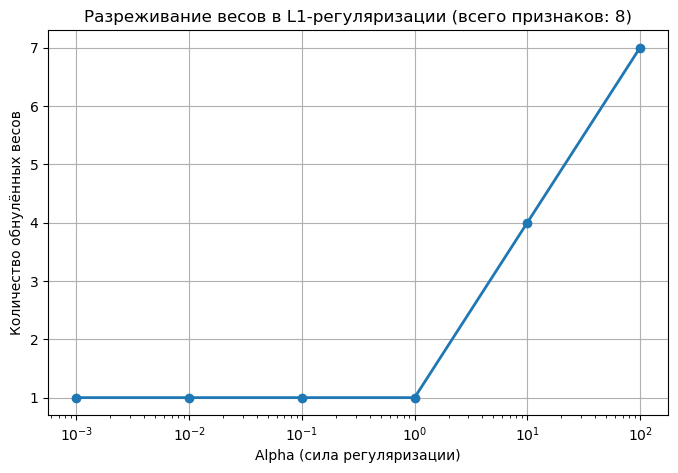

При alpha=0.01 обнулено 1 из 8 признаков
При alpha=1.0 обнулено 1 из 8 признаков
При alpha=1.0 обнулено 4 из 8 признаков

Какие признаки остались при alpha = 10.0:
  month: 14.1685
  is_weekend: -18.1340
  is_night: -43.1304
  distance_km: 348.0242


In [84]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
zero_counts = []

# Имена всех признаков после трансформации
feature_names = numeric_features + list(
    preprocessor.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)
n_features = len(feature_names)

# Для каждого значения альфа обучаем Lasso и считаем обнулённые веса
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', lasso)])
    pipeline.fit(X_train, y_train)  # ← теперь внутри цикла!
    weights = pipeline.named_steps['regressor'].coef_
    zero_counts.append(np.sum(np.abs(weights) < 1e-6))

# График
plt.figure(figsize=(8, 5))
plt.plot(alphas, zero_counts, marker='o', linewidth=2)
plt.xscale('log')
plt.xlabel('Alpha (сила регуляризации)')
plt.ylabel('Количество обнулённых весов')
plt.title(f'Разреживание весов в L1-регуляризации (всего признаков: {n_features})')
plt.grid(True)
plt.show()

print(f"При alpha=0.01 обнулено {zero_counts[1]} из {n_features} признаков")
print(f"При alpha=1.0 обнулено {zero_counts[3]} из {n_features} признаков")
print(f"При alpha=1.0 обнулено {zero_counts[4]} из {n_features} признаков")


print("\nКакие признаки остались при alpha = 10.0:")

# Обучаем Lasso с alpha=10.0
lasso = Lasso(alpha=10.0, max_iter=10000)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', lasso)])
pipeline.fit(X_train, y_train)

weights = pipeline.named_steps['regressor'].coef_

# Выводим признаков с ненулевыми весами
for name, weight in zip(feature_names, weights):
    if abs(weight) > 1e-6:
        print(f"  {name}: {weight:.4f}")

    

График показывает, что с ростом alpha количество обнулённых весов увеличивается. Самые важные признаки: month, is_weekend, is_night, distance_km

## Анализ важности признаков (Random Forest)

Random Forest показывает, какие признаки сильнее всего влияют на предсказание времени поездки

Random Forest измеряет важность признаков по тому, насколько они улучшают разбиения деревьев



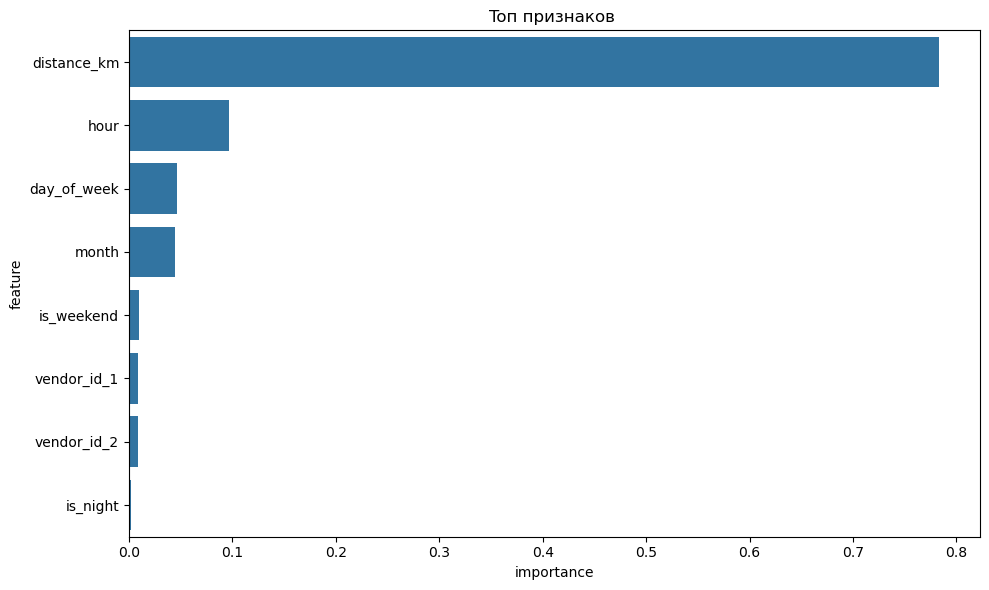


 Самые важные признаки:
       feature  importance
5  distance_km    0.783607
0         hour    0.096406
1  day_of_week    0.046684
2        month    0.044031
3   is_weekend    0.009244


In [85]:
# Обучаем Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# n_estimators=100 — 100 деревьев в лесу, random_state=42 — фиксируем случайность, n_jobs=-1 — все ядра процессора
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', rf)])
pipeline_rf.fit(X_train, y_train)

# Забираем важности
importances = pipeline_rf.named_steps['regressor'].feature_importances_
#feature_importances_ - показывает, какой вклад каждый признак вносит в предсказание


feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
feat_imp = feat_imp.sort_values('importance', ascending=False)

# График
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(8), x='importance', y='feature')
plt.title('Toп признаков ')
plt.tight_layout()
plt.show()

# Вывод
print("\n Самые важные признаки:")
print(feat_imp.head(5))

Расстояние — ключевой фактор.

## PyTorch нейросеть

In [93]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train_t = torch.tensor(X_train_transformed[:3000], dtype=torch.float32)
y_train_t = torch.tensor(y_train.values[:3000], dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test_transformed[:500], dtype=torch.float32)
y_test_t = torch.tensor(y_test.values[:500], dtype=torch.float32).reshape(-1, 1)

#архитектура
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # 1 слой: из входных признаков (7) в 64 нейрона
        self.layer1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        # 2 слой: из 64 в 32 нейрона
        self.layer2 = nn.Linear(64, 32)# функция активации
        # 3 слой: из 32 в 1 (предсказание времени)
        self.layer3 = nn.Linear(32, 1)
    
    #Прямой проход
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

model = SimpleNN(X_train_t.shape[1])
criterion = nn.MSELoss()
# Оптимизатор - адаптивный градиентный спуск, lr=0.01 — скорость обучения
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
    model.train() # Модель в режим обучения
    optimizer.zero_grad()# Обнулеие градиентов
    pred = model(X_train_t) # Прямой проход: предсказание
    loss = criterion(pred, y_train_t) # Счит ошибку
    loss.backward() # Обратный проход: счит град
    optimizer.step() # Обновление весов
    
    if epoch % 20 == 0:
        print(f"  Epoch {epoch}, Loss: {loss.item():.4f}")
        
# Модель в режим оценки, откл град
model.eval()
with torch.no_grad():
    y_pred_nn = model(X_test_t).numpy()
    y_true_nn = y_test_t.numpy()

rmse_nn = np.sqrt(mean_squared_error(y_true_nn, y_pred_nn))
r2_nn = r2_score(y_true_nn, y_pred_nn)

print(f"\nPyTorch NN на тесте:")
print(f"  RMSE: {rmse_nn:.2f} сек")
print(f"  R2: {r2_nn:.4f}")


  Epoch 0, Loss: 830507.6250
  Epoch 20, Loss: 829369.3750
  Epoch 40, Loss: 827161.0000

PyTorch NN на тесте:
  RMSE: 916.49 сек
  R2: -2.2285


В итоге нейросеть предсказывает хуже, чем простое среднее значение
Возможно, недостаточно данных для обучения или масштаб данных подвел